In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import ast

from vitalnodes.utils.load_network import load_network
from vitalnodes.orchestrator import compute_metrics, compute_metric, get_metric_names

In [3]:
os.chdir("..")

In [4]:
ABM_contact_network = load_network("ABM-contacts")

Loading ABM network: 100%|██████████| 240/240 [00:03<00:00, 63.19it/s]


In [ ]:
metrics = get_metric_names()
metrics.remove("tgc")
metrics_over_time = compute_metrics(ABM_contact_network, metrics, parallel=True, n_processes=40)

metrics_over_time_df = pd.DataFrame(metrics_over_time)
metrics_over_time_df.to_csv("notebooks/metrics_over_time_abm.csv", index=False)

Graph at index 0 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 2 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 1 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 3 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 5 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 4 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 6 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 7 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 

In [5]:
metrics_over_time_df = pd.read_csv("notebooks/metrics_over_time_abm.csv")

In [29]:
excluded_metrics = ["dk+", "igc+", "gc+", "ninl_layer0", "mcde_weighted", "dsr_agg", "gli_new", "local_h_index", "tgc"]

all_metrics = get_metric_names()
#selected_metrics = [metric for metric in all_metrics if metric not in excluded_metrics]
selected_metrics = ["degree", "igc"]

filtered_metrics_df = metrics_over_time_df[selected_metrics]

In [30]:
# Convert the DataFrame to a dictionary
metrics_over_time = filtered_metrics_df.to_dict(orient="records")

# Parse string representations of dictionaries into actual dictionaries
for snapshot in metrics_over_time:
    for metric, value in snapshot.items():
        if isinstance(value, str):  # Check if the value is a string
            try:
                snapshot[metric] = ast.literal_eval(value)  # Convert string to dictionary
            except (ValueError, SyntaxError):
                pass  # Leave the value as is if it cannot be converted

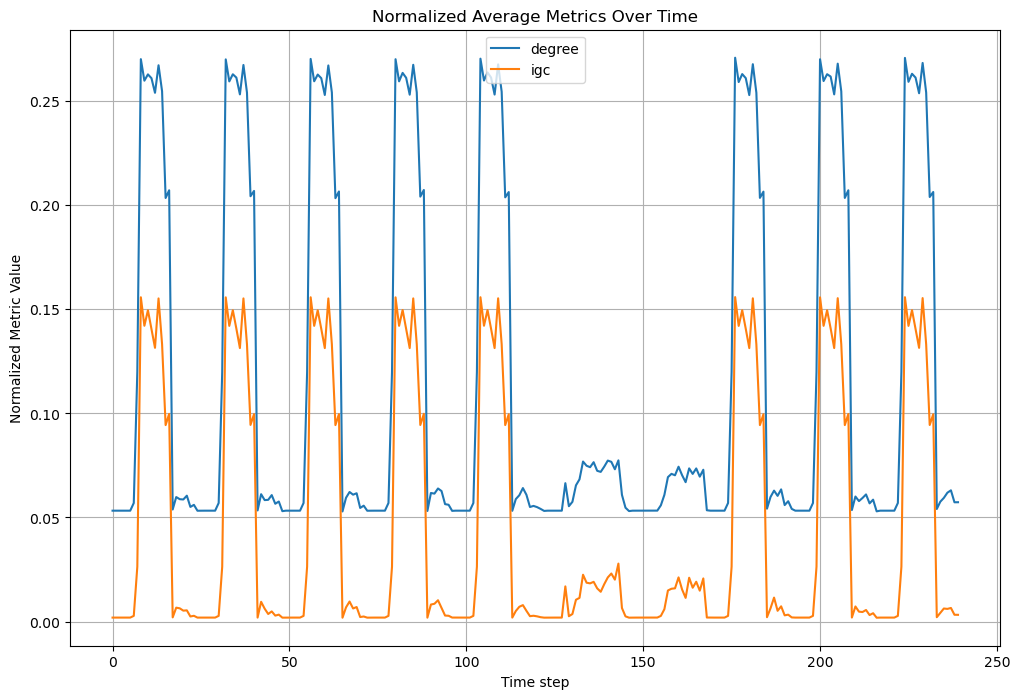

In [31]:
# Extract metrics for plotting
metric_names = metrics_over_time[0].keys()  # Assuming all snapshots have the same metrics
time_steps = range(len(metrics_over_time))

# Initialize a dictionary to store normalized average values for each metric
normalized_metrics_over_time = {metric: [] for metric in metric_names}

# Calculate the average of each metric over all nodes at each time step
for metric in metric_names:
    all_values = []  # Collect all values for normalization
    for t in time_steps:
        node_values = metrics_over_time[t][metric].values()
        # Filter out None values
        valid_values = [value for value in node_values if value is not None]
        all_values.extend(valid_values)

    # Normalize the values (min-max scaling)
    if all_values:
        min_val = min(all_values)
        max_val = max(all_values)
        range_val = max_val - min_val if max_val != min_val else 1  # Avoid division by zero

        for t in time_steps:
            node_values = metrics_over_time[t][metric].values()
            valid_values = [value for value in node_values if value is not None]
            avg_value = sum(valid_values) / len(valid_values) if valid_values else 0
            normalized_value = (avg_value - min_val) / range_val
            normalized_metrics_over_time[metric].append(normalized_value)
    else:
        normalized_metrics_over_time[metric] = [0] * len(time_steps)  # Default to 0 if no valid values

# Plot all normalized metrics in the same figure
plt.figure(figsize=(12, 8))
for metric, values in normalized_metrics_over_time.items():
    plt.plot(time_steps, values, label=metric)

plt.title("Normalized Average Metrics Over Time")
plt.xlabel("Time step")
plt.ylabel("Normalized Metric Value")
plt.legend()
plt.grid(True)
plt.show()

school/home contacts

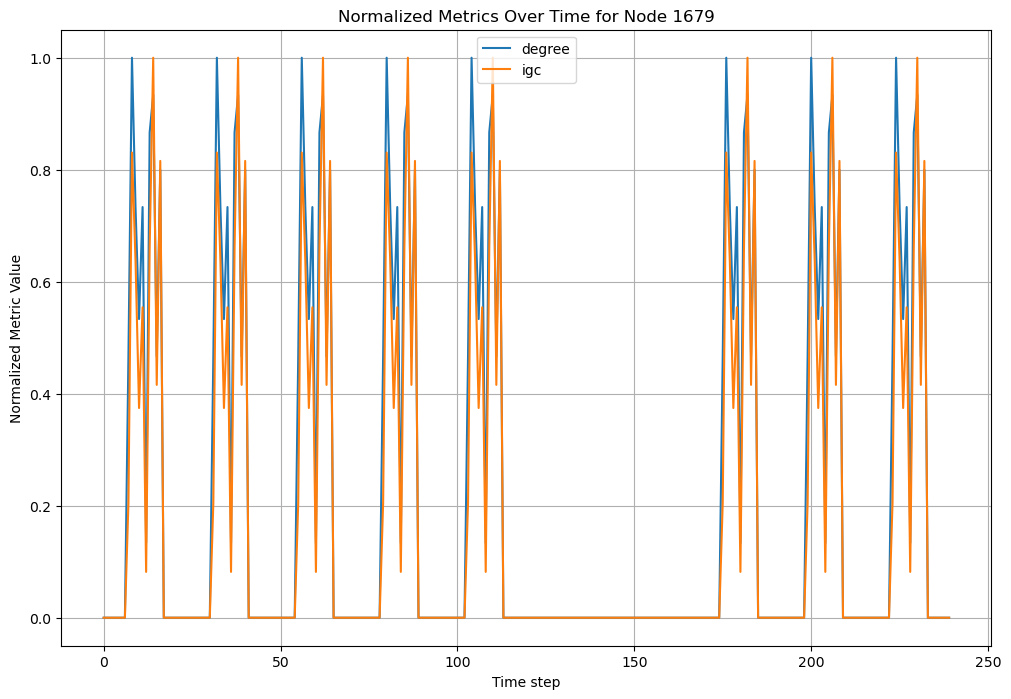

In [32]:
# Select a specific node
node_index = 31  # Change this index to select a different node
specific_node = list(ABM_contact_network[0].nodes())[node_index]  

# Extract metrics for the specific node over time
node_metrics_over_time = {metric: [] for metric in metric_names}
for t in range(len(metrics_over_time)):
    for metric in metric_names:
        node_value = metrics_over_time[t][metric].get(specific_node, None)
        node_metrics_over_time[metric].append(node_value if node_value is not None else 0)

# Normalize each metric over time for the specific node
normalized_node_metrics = {}
for metric, values in node_metrics_over_time.items():
    min_val = min(values)
    max_val = max(values)
    range_val = max_val - min_val if max_val != min_val else 1  # Avoid division by zero
    normalized_values = [(value - min_val) / range_val for value in values]
    normalized_node_metrics[metric] = normalized_values

# Plot the normalized metrics for the specific node
plt.figure(figsize=(12, 8))
for metric, values in normalized_node_metrics.items():
    plt.plot(range(len(values)), values, label=metric)
plt.title(f"Normalized Metrics Over Time for Node {specific_node}")
plt.xlabel("Time step")
plt.ylabel("Normalized Metric Value")
plt.legend()
plt.grid(True)
plt.show()

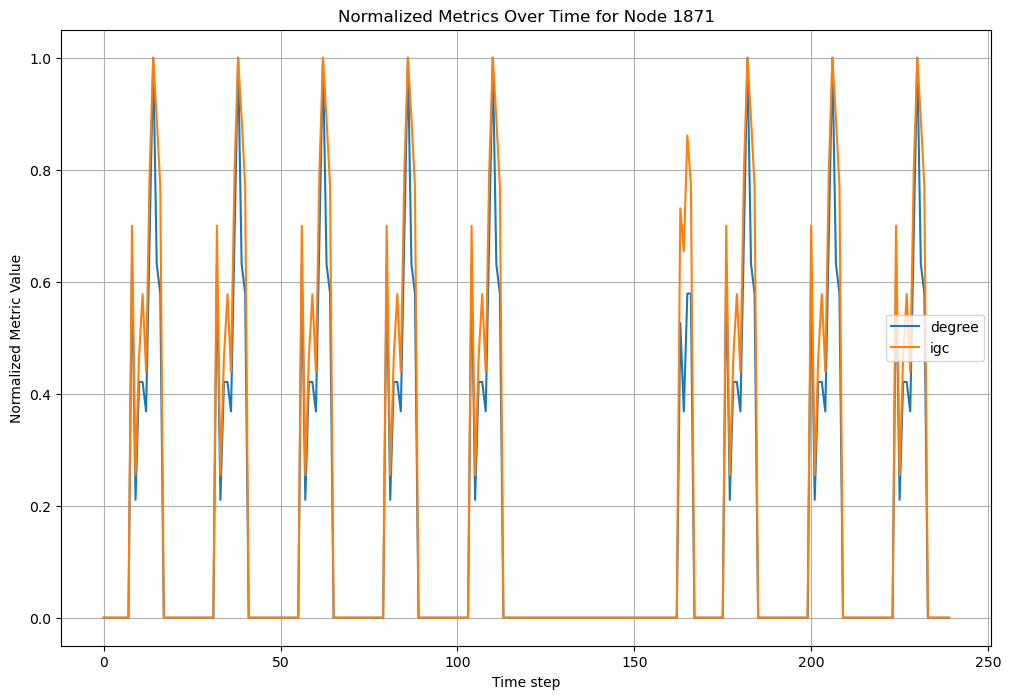

In [37]:
# Select a specific node
node_index = 31 + 192 # Change this index to select a different node
specific_node = list(ABM_contact_network[0].nodes())[node_index]  

# Extract metrics for the specific node over time
node_metrics_over_time = {metric: [] for metric in metric_names}
for t in range(len(metrics_over_time)):
    for metric in metric_names:
        node_value = metrics_over_time[t][metric].get(specific_node, None)
        node_metrics_over_time[metric].append(node_value if node_value is not None else 0)

# Normalize each metric over time for the specific node
normalized_node_metrics = {}
for metric, values in node_metrics_over_time.items():
    min_val = min(values)
    max_val = max(values)
    range_val = max_val - min_val if max_val != min_val else 1  # Avoid division by zero
    normalized_values = [(value - min_val) / range_val for value in values]
    normalized_node_metrics[metric] = normalized_values

# Plot the normalized metrics for the specific node
plt.figure(figsize=(12, 8))
for metric, values in normalized_node_metrics.items():
    plt.plot(range(len(values)), values, label=metric)
plt.title(f"Normalized Metrics Over Time for Node {specific_node}")
plt.xlabel("Time step")
plt.ylabel("Normalized Metric Value")
plt.legend()
plt.grid(True)
plt.show()

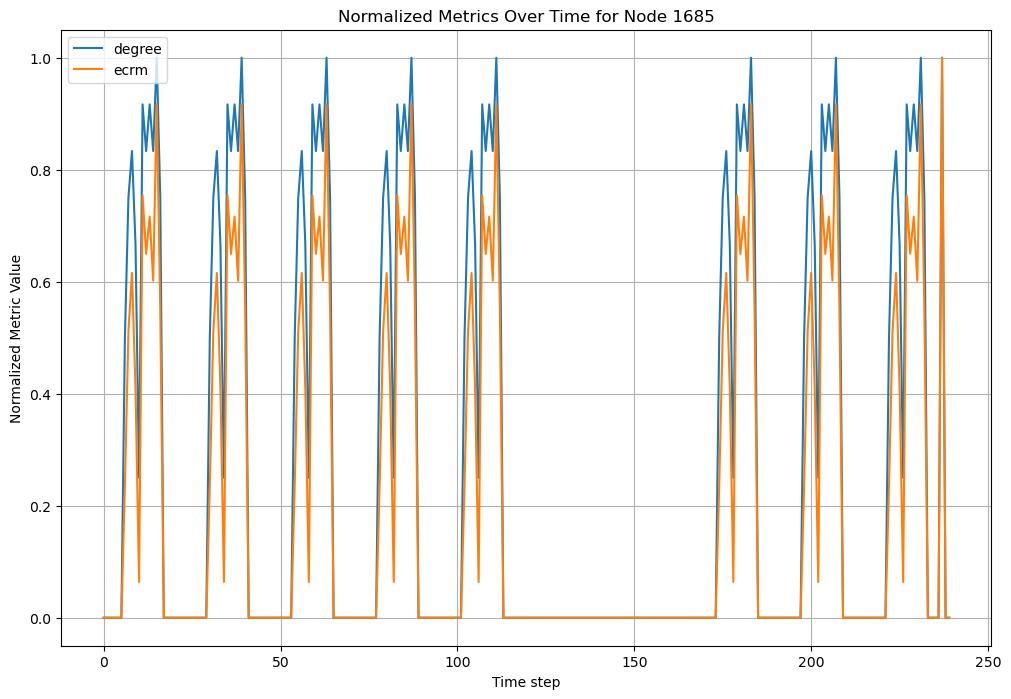

In [28]:
# Select a specific node
node_index = 37 # Change this index to select a different node
specific_node = list(ABM_contact_network[0].nodes())[node_index]  

# Extract metrics for the specific node over time
node_metrics_over_time = {metric: [] for metric in metric_names}
for t in range(len(metrics_over_time)):
    for metric in metric_names:
        node_value = metrics_over_time[t][metric].get(specific_node, None)
        node_metrics_over_time[metric].append(node_value if node_value is not None else 0)

# Normalize each metric over time for the specific node
normalized_node_metrics = {}
for metric, values in node_metrics_over_time.items():
    min_val = min(values)
    max_val = max(values)
    range_val = max_val - min_val if max_val != min_val else 1  # Avoid division by zero
    normalized_values = [(value - min_val) / range_val for value in values]
    normalized_node_metrics[metric] = normalized_values

# Plot the normalized metrics for the specific node
plt.figure(figsize=(12, 8))
for metric, values in normalized_node_metrics.items():
    plt.plot(range(len(values)), values, label=metric)
plt.title(f"Normalized Metrics Over Time for Node {specific_node}")
plt.xlabel("Time step")
plt.ylabel("Normalized Metric Value")
plt.legend()
plt.grid(True)
plt.show()